# 03 · El examen con el que se corrige al agente

**Qué pregunta responde este cuaderno.** ¿Con qué preguntas vamos a medir si el agente responde bien, y de dónde sale la respuesta correcta de cada una?

Un **golden set** es un examen con las soluciones ya escritas: 20 preguntas sobre los informes cuya respuesta conocemos de antemano. Sin él no se puede decir si una mejora mejora algo; con él, cada cambio se puede medir. Las respuestas correctas no se teclean a mano: se leen de los datos, porque un dígito mal copiado contaminaría en silencio todas las métricas del proyecto.

Aparte de las 20 se guarda un segundo fichero con seis **huecos**: preguntas cuya respuesta correcta es «ese dato no está en el corpus».
**Requisitos:** R06, R07, R14 · **Guía:** [10](../docs/10_skill_golden_set.md) · **Salidas:** `golden/golden_propio.jsonl` y `golden/golden_huecos.jsonl` · No llama a ninguna API.

In [1]:
# Arranque (igual en todos los notebooks): localiza la raíz del repo y hace importable src/
import sys, pathlib, json, re, textwrap
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(RAIZ / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from agente10k import config, datos

# Paleta común a los cuadernos 03 y 04: un color por familia de pregunta.
COLOR_FAMILIA = {"numerica": "#4C78A8", "extractiva": "#59A14F",
                 "comparativa": "#F28E2B", "hueco": "#8F63B8"}
ORDEN_EMPRESAS = ["NVDA", "MSFT", "AAPL", "GOOGL", "META", "AMZN"]
plt.rcParams.update({"figure.dpi": 115, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

GOLDEN = pathlib.Path(getattr(config, "GOLDEN", RAIZ / "golden"))
GOLDEN.mkdir(parents=True, exist_ok=True)

AUTOR = "grupo-3"          # <<< PON AQUÍ EL IDENTIFICADOR DE VUESTRO GRUPO
PREFIJO = AUTOR.replace("grupo-", "g")   # ids del tipo g3-001

secciones = datos.cargar_secciones()
chunks    = datos.cargar_chunks()
xbrl      = datos.cargar_xbrl()

print(f"{len(secciones)} secciones · {len(chunks)} fragmentos · {len(xbrl)} hechos XBRL")
print("El golden se guardará en:", GOLDEN)
print("Este notebook NO llama a ninguna API.")

48 secciones · 1749 fragmentos · 135 hechos XBRL
El golden se guardará en: C:\Users\Usuario\Downloads\10k-financial-agent\golden
Este notebook NO llama a ninguna API.


## 0. Quién valida las preguntas

El código que carga, guarda y valida el golden vive en `src/agente10k/evaluacion.py`, no en este cuaderno. El validador comprueba cuatro cosas antes de dejar guardar nada: que la cifra coincide con la que reportó la empresa, que la frase citada existe literalmente en el informe, que sus posiciones cuadran y que la herramienta esperada existe.

In [2]:
from agente10k import evaluacion
import importlib
importlib.reload(evaluacion)

faltan = [f for f in ("cargar_golden", "guardar_golden", "validar_golden")
          if not hasattr(evaluacion, f)]
assert not faltan, f"Faltan funciones en evaluacion.py: {faltan}"
print("evaluacion.py listo:", [f for f in dir(evaluacion) if not f.startswith("_")])

evaluacion.py listo: ['CAMPOS', 'FAMILIAS', 'HERRAMIENTAS', 'ITEMS', 'MAX_PALABRAS_ANCLA', 'PASOS_RETRIEVAL', 'Path', 'RETRIEVAL_ARTEFACTO_SELECCIONADO', 'annotations', 'cargar_golden', 'config', 'datos', 'detalle_retrieval', 'diagnosticar_filtros', 'diagnosticar_retrieval_agente', 'evaluar', 'evaluar_cifra', 'evaluar_cita', 'evaluar_trayectoria', 'exportar_retrieval', 'filtros_oraculo', 'guardar_golden', 'hashlib', 'json', 'math', 'medir_retrieval', 'normalizar', 'normalizar_ticker', 'pd', 'preparar_retrieval', 'recall_at_k', 'resumir_retrieval', 'retrieval', 'tabla_comparativa', 'techos_retrieval', 'textos_retrieval', 'time', 'validar_golden', 'warnings']


## 1. Cuatro familias de preguntas, porque miden cosas distintas

Un examen de 20 preguntas del mismo tipo mide una sola habilidad. Estas cuatro familias miden cuatro:

- **Numérica** (7 preguntas): pide una cifra exacta. Comprueba que el agente va a la fuente autorizada y no la copia del texto.
- **Extractiva** (6): pide qué dice el informe sobre algo. Comprueba que el agente encuentra el pasaje y lo cita de verdad.
- **Comparativa** (7): pide cómo cambió una magnitud entre dos ejercicios y por qué. No se contesta con una sola consulta: hay que buscar dos veces y explicar. Es la familia donde de verdad hace falta un agente.
- **Hueco** (6, en un fichero aparte): pregunta por un dato que no existe en el corpus. Acierta quien dice que no está; falla quien se lo inventa.

El enunciado exige al menos 6 comparativas; ponemos 7 por margen. Después se comprueba la cobertura: las seis empresas, los dos ejercicios y los cuatro apartados del informe tienen que aparecer. Un examen concentrado en una empresa mediría una esquina del corpus, no el corpus.

In [3]:
PLAN = pd.DataFrame([
    ("numerica",    7, ["get_xbrl_fact"],                   "el guardrail contra XBRL"),
    ("extractiva",  6, ["search_filings"],                  "retrieval y trazabilidad"),
    ("comparativa", 7, ["get_xbrl_fact", "search_filings"], "descomponer y comparar"),
], columns=["familia", "cuántas", "herramienta_esperada", "qué mide"])
display(PLAN)
print("total:", PLAN["cuántas"].sum())

def hecho(ticker, fiscal_year, concept):
    """La fila de xbrl_facts para ese ticker/ejercicio/concepto. KeyError si no está."""
    fila = xbrl[(xbrl["ticker"] == ticker)
                & (xbrl["fiscal_year"].astype(int) == int(fiscal_year))
                & (xbrl["concept"] == concept)]
    if fila.empty:
        disponibles = sorted(xbrl.loc[(xbrl["ticker"] == ticker)
                                      & (xbrl["fiscal_year"].astype(int) == int(fiscal_year)),
                                      "concept"].unique())
        raise KeyError(f"{ticker} FY{fiscal_year} no reporta '{concept}'. "
                       f"Tiene: {disponibles}")
    return fila.iloc[0]

def unidad_de(concept, fila):
    """La unidad, de la columna del parquet si existe; si no, inferida del concepto."""
    for col in ("unit", "unidad", "units"):
        if col in fila.index and pd.notna(fila[col]):
            return str(fila[col])
    if "PerShare" in concept:
        return "USD/acción"
    if "Shares" in concept:
        return "acciones"
    return "USD"

def fmt_es(x, dec=0):
    """1234567.0 -> '1.234.567'  ·  2.97 -> '2,97'"""
    return f"{x:,.{dec}f}".replace(",", "@").replace(".", ",").replace("@", ".")

# Qué conceptos existen de verdad, por si hay que ajustar alguna spec
display(xbrl.pivot_table(index="concept", columns="ticker", values="value",
                         aggfunc="count", fill_value=0))

,familia,cuántas,herramienta_esperada,qué mide
0,numerica,7,[get_xbrl_fact],el guardrail contra XBRL
1,extractiva,6,[search_filings],retrieval y trazabilidad
2,comparativa,7,"[get_xbrl_fact, search_filings]",descomponer y comparar


total: 20


ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA
concept,,,,,,
Assets,2,2,2,2,2,2
CashAndCashEquivalentsAtCarryingValue,2,2,2,2,2,2
EarningsPerShareBasic,2,2,2,2,2,2
EarningsPerShareDiluted,2,2,2,2,2,2
GrossProfit,2,0,0,0,2,2
Liabilities,2,0,2,2,2,2
NetCashProvidedByUsedInOperatingActivities,2,2,2,2,2,2
NetIncomeLoss,2,2,2,2,2,2
OperatingIncomeLoss,2,2,2,2,2,2


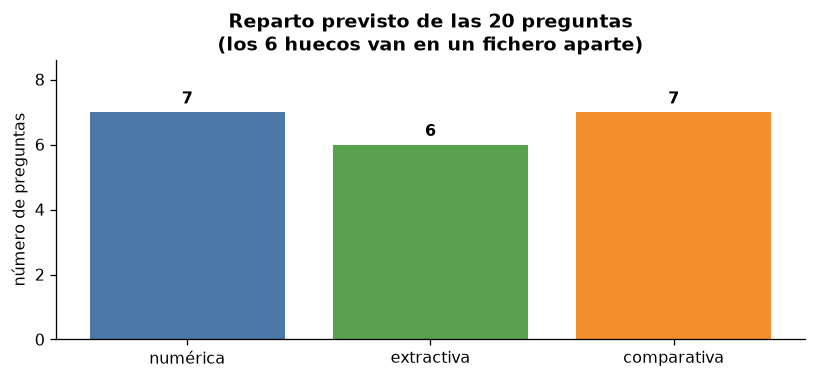

numerica      7 preguntas · mide el guardrail contra XBRL
extractiva    6 preguntas · mide retrieval y trazabilidad
comparativa   7 preguntas · mide descomponer y comparar


In [4]:
# El reparto previsto, de un vistazo (el recuento definitivo se comprueba al final)
plan_grafico = PLAN.set_index("familia")["cuántas"]

fig, ax = plt.subplots(figsize=(7.2, 3.4))
barras = ax.bar(plan_grafico.index, plan_grafico.values,
                color=[COLOR_FAMILIA[f] for f in plan_grafico.index])
ax.bar_label(barras, padding=3, fontweight="bold")
ax.set_ylabel("número de preguntas")
ax.set_xticks(range(len(plan_grafico)), ["numérica", "extractiva", "comparativa"])
ax.set_ylim(0, plan_grafico.max() + 1.6)
ax.set_title("Reparto previsto de las 20 preguntas\n(los 6 huecos van en un fichero aparte)")
plt.tight_layout()
plt.show()

for familia, fila in PLAN.set_index("familia").iterrows():
    print(f"{familia:12s} {fila['cuántas']:2d} preguntas · mide {fila['qué mide']}")

**Qué nos dice esto:** el examen mide cuatro habilidades distintas —dar la cifra exacta, citar el pasaje, comparar dos ejercicios y reconocer que un dato no existe—, no cuatro veces la misma.

## 2. Numéricas: la cifra se lee del fichero, no se teclea

Siete preguntas de cifra exacta. El valor correcto se lee de `xbrl_facts.parquet`, la fuente autorizada, en vez de copiarlo a mano.

Los conceptos se miran uno a uno: NVIDIA publica sus ingresos bajo el nombre `Revenues` y Microsoft bajo otro mucho más largo. Suponerlo por analogía es uno de los errores clásicos de este corpus.

In [5]:
# Ningún (ticker, concepto) de aquí se repite en las comparativas.
SPEC_NUMERICAS = [
    ("NVDA",  2024, "GrossProfit",                                "el beneficio bruto", 0),
    ("MSFT",  2025, "ResearchAndDevelopmentExpense",              "el gasto en I+D", 0),
    ("AAPL",  2025, "EarningsPerShareDiluted",                    "el beneficio por acción diluido", 2),
    ("GOOGL", 2024, "StockholdersEquity",                         "el patrimonio neto", 0),
    ("META",  2025, "NetCashProvidedByUsedInOperatingActivities", "el flujo de caja operativo", 0),
    ("AMZN",  2024, "StockholdersEquity",                         "el patrimonio neto", 0),
    ("NVDA",  2025, "Liabilities",                                "el pasivo total", 0),
]

numericas = []
for i, (ticker, fy, concepto, etiqueta, dec) in enumerate(SPEC_NUMERICAS, start=1):
    fila = hecho(ticker, fy, concepto)
    valor = float(fila["value"])
    unidad = unidad_de(concepto, fila)
    numericas.append({
        "id": f"{PREFIJO}-{i:03d}",
        "pregunta": f"¿Cuál fue {etiqueta} de {ticker} en el ejercicio fiscal {fy}?",
        "familia": "numerica",
        "ticker": ticker,
        "fiscal_year": fy,
        "respuesta_esperada": f"{fmt_es(valor, dec)} {unidad}",
        "cifra_esperada": valor,
        "unidad": unidad,
        "concept_xbrl": concepto,
        "item_esperado": None,
        "ancla_texto": None,
        "ancla_inicio": None,
        "ancla_fin": None,
        "chunk_id_esperado": None,
        "herramienta_esperada": ["get_xbrl_fact"],
        "autor": AUTOR,
    })

display(pd.DataFrame(numericas)[["id", "ticker", "fiscal_year", "concept_xbrl",
                                 "respuesta_esperada"]])
print(f"{len(numericas)} numéricas construidas desde XBRL, sin teclear ninguna cifra.")

,id,ticker,fiscal_year,concept_xbrl,respuesta_esperada
0,g3-001,NVDA,2024,GrossProfit,44.301.000.000 USD
1,g3-002,MSFT,2025,ResearchAndDevelopmentExpense,32.488.000.000 USD
2,g3-003,AAPL,2025,EarningsPerShareDiluted,"7,46 USD/shares"
3,g3-004,GOOGL,2024,StockholdersEquity,325.084.000.000 USD
4,g3-005,META,2025,NetCashProvidedByUsedInOperatingActivities,115.800.000.000 USD
5,g3-006,AMZN,2024,StockholdersEquity,285.970.000.000 USD
6,g3-007,NVDA,2025,Liabilities,32.274.000.000 USD


7 numéricas construidas desde XBRL, sin teclear ninguna cifra.


**Qué nos dice esto:** las siete respuestas correctas salen del fichero de cifras oficiales. Ningún número del examen se ha escrito a mano, así que no hay riesgo de que una errata falsee todas las métricas.

## 3. Extractivas: la verdad es una frase del informe

Aquí la respuesta correcta no es un número, sino una frase literal del 10-K. Se ancla a la frase y no al identificador del fragmento que la contiene: si mañana se trocea el corpus de otra forma, los identificadores cambian y la frase sigue valiendo.

Primero se buscan frases candidatas dentro de la sección y después se elige una; el código calcula en qué posición exacta del texto empieza y acaba.

In [6]:
def frases_de(ticker, fiscal_year, item):
    fila = secciones[(secciones["ticker"] == ticker)
                     & (secciones["fiscal_year"].astype(int) == int(fiscal_year))
                     & (secciones["item"] == item)]
    if fila.empty:
        raise KeyError(f"No existe {ticker} FY{fiscal_year} item {item}")
    texto = fila.iloc[0]["texto"]
    trozos = re.split(r"(?<=[.!?])\s+(?=[A-Z(\"'])", texto)
    return texto, [t.strip() for t in trozos if t.strip()]

def buscar_frases(ticker, fiscal_year, item, terminos, minp=8, maxp=40):
    """Frases de esa sección que contienen TODOS los términos (en inglés)."""
    _, fs = frases_de(ticker, fiscal_year, item)
    return [f for f in fs
            if minp <= len(f.split()) <= maxp
            and all(t.lower() in f.lower() for t in terminos)]

def candidatas(ticker, fiscal_year, item, *conjuntos, n=6, mostrar=True):
    """Prueba cada conjunto de términos en orden y se queda con el primero que dé algo."""
    for terminos in conjuntos:
        hallazgos = buscar_frases(ticker, fiscal_year, item, terminos)
        if hallazgos:
            if mostrar:
                print(f"── {ticker} FY{fiscal_year} item {item} · términos {terminos} "
                      f"· {len(hallazgos)} candidatas (muestro {min(n, len(hallazgos))})\n")
                for j, f in enumerate(hallazgos[:n]):
                    print(f"  [{j}] ({len(f.split())} palabras)")
                    print(textwrap.indent(textwrap.fill(f, 92), "      "), "\n")
            return hallazgos
    if mostrar:
        print(f"── {ticker} FY{fiscal_year} item {item} · SIN CANDIDATAS con {conjuntos}\n")
    return []

In [7]:
ESPEC_EXTRACTIVAS = [
    dict(clave="msft-ia",     ticker="MSFT",  fy=2025, item="1A",
         pregunta="Según su 10-K de FY2025, ¿qué dice Microsoft sobre el uso indebido de sus sistemas de IA por parte de terceros?",
         terminos=[("AI", "misuse"), ("AI systems",), ("artificial intelligence", "risk")]),
    dict(clave="nvda-supply", ticker="NVDA",  fy=2025, item="1A",
         pregunta="¿Qué riesgo declara NVIDIA en FY2025 por depender de un número reducido de proveedores de fabricación?",
         terminos=[("suppliers",)]),
    dict(clave="aapl-fx",     ticker="AAPL",  fy=2024, item="7A",
         pregunta="¿Cómo describe Apple su exposición al riesgo de tipo de cambio en FY2024?",
         terminos=[("foreign currency", "exposure"), ("foreign exchange",), ("currency",)]),
    dict(clave="amzn-aws",    ticker="AMZN",  fy=2025, item="7",
         pregunta="¿Qué dice la dirección de Amazon en FY2025 sobre la evolución de AWS?",
         terminos=[("AWS", "increase"), ("AWS", "sales"), ("AWS",)]),
    dict(clave="googl-anti",  ticker="GOOGL", fy=2025, item="1A",
         pregunta="¿Qué riesgo regulatorio en materia de competencia declara Alphabet en FY2025?",
         terminos=[("antitrust",), ("competition", "regulatory"), ("regulatory", "investigations")]),
    dict(clave="meta-item8",  ticker="META",  fy=2024, item="8",
         pregunta="¿Qué indica Meta en sus estados financieros de FY2024 sobre sus obligaciones contractuales o arrendamientos?",
         terminos=[("operating lease",), ("lease", "liabilities"), ("commitments",)]),
]

CANDIDATAS = {}
for e in ESPEC_EXTRACTIVAS:
    CANDIDATAS[e["clave"]] = candidatas(e["ticker"], e["fy"], e["item"], *e["terminos"])

print({k: len(v) for k, v in CANDIDATAS.items()})

── MSFT FY2025 item 1A · términos ('AI', 'misuse') · 2 candidatas (muestro 2)

  [0] (39 palabras)
      While we are committed to detecting and controlling such misuse of our cloud-based and AI
      services, our efforts may not be effective, and we may incur reputational damage or
      experience adverse impacts to our business and results of operations. 

  [1] (37 palabras)
      Relatedly, despite our efforts to continuously improve security controls, it is possible
      that we may fail to identify or mitigate insider threat activities that could lead to the
      misuse of our systems or customer and user data. 

── NVDA FY2025 item 1A · términos ('suppliers',) · 10 candidatas (muestro 6)

  [0] (27 palabras)
      We continue to increase our supply and capacity purchases with existing and new suppliers to
      support our demand projections and increasing complexity of our data center products. 

  [1] (31 palabras)
      The increased purchase volumes and integration of ne

In [8]:
SELECCION = {
    "msft-ia":     0,
    "nvda-supply": 1,
    "aapl-fx":     0,
    "amzn-aws":    0,
    "googl-anti":  0,
    "meta-item8":  0,
}

def anclar(ticker, fiscal_year, item, frase):
    texto, _ = frases_de(ticker, fiscal_year, item)
    pos = texto.find(frase)
    if pos == -1:
        raise ValueError(f"La frase no aparece literal en {ticker} FY{fiscal_year} {item}.")
    if texto.find(frase, pos + 1) != -1:
        print(f"AVISO: el ancla aparece más de una vez en {ticker} FY{fiscal_year} {item}. "
              "Elige otra candidata si quieres un ancla inequívoca.")
    trozos = chunks[(chunks["ticker"] == ticker)
                    & (chunks["fiscal_year"].astype(int) == int(fiscal_year))
                    & (chunks["item"] == item)]
    cid = next((t.chunk_id for t in trozos.itertuples() if frase in t.texto), None)
    if cid is None:
        print(f"AVISO: ningún fragmento contiene el ancla entera ({ticker} FY{fiscal_year} "
              f"{item}). Cae en un corte del troceado; informativo, no rompe nada.")
    return {"item_esperado": item, "ancla_texto": frase,
            "ancla_inicio": pos, "ancla_fin": pos + len(frase),
            "chunk_id_esperado": cid}

extractivas = []
for i, e in enumerate(ESPEC_EXTRACTIVAS, start=len(numericas) + 1):
    opciones = CANDIDATAS[e["clave"]]
    assert opciones, (f"{e['clave']}: sin candidatas. Afloja los términos en "
                      f"ESPEC_EXTRACTIVAS y vuelve a ejecutar la celda anterior.")
    idx = SELECCION[e["clave"]]
    assert idx < len(opciones), f"{e['clave']}: solo hay {len(opciones)} candidatas, pediste la {idx}"
    frase = opciones[idx]

    registro = {
        "id": f"{PREFIJO}-{i:03d}",
        "pregunta": e["pregunta"],
        "familia": "extractiva",
        "ticker": e["ticker"],
        "fiscal_year": e["fy"],
        "respuesta_esperada": "",
        "cifra_esperada": None,
        "unidad": None,
        "concept_xbrl": None,
        "herramienta_esperada": ["search_filings"],
        "autor": AUTOR,
        **anclar(e["ticker"], e["fy"], e["item"], frase),
    }
    registro["respuesta_esperada"] = (
        f"Lo que el informe afirma en Item {e['item']}: «{registro['ancla_texto']}»")
    extractivas.append(registro)

tabla = pd.DataFrame(extractivas)
display(tabla[["id", "ticker", "fiscal_year", "item_esperado",
               "ancla_inicio", "ancla_fin", "chunk_id_esperado"]])
for r in extractivas:
    print(f"\n{r['id']} · {r['ticker']} FY{r['fiscal_year']} item {r['item_esperado']}")
    print(textwrap.fill(r["ancla_texto"], 92))

,id,ticker,fiscal_year,item_esperado,ancla_inicio,ancla_fin,chunk_id_esperado
0,g3-008,MSFT,2025,1A,9317,9560,MSFT-2025-1A-0004
1,g3-009,NVDA,2025,1A,15076,15308,NVDA-2025-1A-0006
2,g3-010,AAPL,2024,7A,2057,2219,AAPL-2024-7A-0001
3,g3-011,AMZN,2025,7,26765,26825,AMZN-2025-7-0013
4,g3-012,GOOGL,2025,1A,58086,58260,GOOGL-2025-1A-0025
5,g3-013,META,2024,8,42935,43041,META-2024-8-0025



g3-008 · MSFT FY2025 item 1A
While we are committed to detecting and controlling such misuse of our cloud-based and AI
services, our efforts may not be effective, and we may incur reputational damage or
experience adverse impacts to our business and results of operations.

g3-009 · NVDA FY2025 item 1A
The increased purchase volumes and integration of new suppliers and contract manufacturers
into our supply chain creates more complexity in managing multiple suppliers with variations
in production planning, execution and logistics.

g3-010 · AAPL FY2024 item 7A
However, the Company may choose to not hedge certain foreign currency exposures for a
variety of reasons, including accounting considerations or prohibitive cost.

g3-011 · AMZN FY2025 item 7
AWS sales increased 20% in 2025, compared to the prior year.

g3-012 · GOOGL FY2025 item 1A
For example, the DOJ and a number of state Attorneys General filed a lawsuit concerning our
Search and Search advertising practices and our complianc

**Qué nos dice esto:** las seis preguntas de texto quedan ancladas a una frase literal y a su posición exacta dentro de la sección. Eso permite comprobar automáticamente si el agente cita de verdad o parafrasea de memoria.

## 4. Comparativas: dos ejercicios y una explicación

Siete preguntas que necesitan dos consultas y una lectura: cuánto valía la magnitud en cada ejercicio y qué dice la dirección sobre el cambio.

El formato oficial de pregunta solo tiene sitio para un ejercicio y una cifra, así que los campos estándar guardan el ejercicio más reciente y se añaden tres campos extra con el ejercicio base y la variación. El validador oficial ignora los campos extra.

In [9]:
ESPEC_COMPARATIVAS = [
    dict(clave="msft-rev",  ticker="MSFT",  base=2024, recien=2025,
         concepto="RevenueFromContractWithCustomerExcludingAssessedTax",
         etiqueta="los ingresos totales", dec=0, item="7",
         terminos=[("revenue", "increased"), ("revenue", "growth"), ("revenue",)]),
    dict(clave="nvda-rev",  ticker="NVDA",  base=2024, recien=2025,
         concepto="Revenues", etiqueta="los ingresos totales", dec=0, item="7",
         terminos=[("demand",)]),
    dict(clave="googl-rev", ticker="GOOGL", base=2024, recien=2025,
         concepto="Revenues", etiqueta="los ingresos totales", dec=0, item="7",
         terminos=[("revenues", "increased"), ("revenue", "growth"), ("revenues",)]),
    dict(clave="meta-rd",   ticker="META",  base=2024, recien=2025,
         concepto="ResearchAndDevelopmentExpense", etiqueta="el gasto en I+D",
         dec=0, item="7",
         terminos=[("research and development", "increased"),
                   ("research and development",), ("expenses", "increased")]),
    dict(clave="aapl-cash", ticker="AAPL",  base=2024, recien=2025,
         concepto="CashAndCashEquivalentsAtCarryingValue",
         etiqueta="la caja y equivalentes", dec=0, item="8",
         terminos=[("cash equivalents",), ("marketable securities",), ("cash",)]),
    dict(clave="amzn-ocf",  ticker="AMZN",  base=2024, recien=2025,
         concepto="NetCashProvidedByUsedInOperatingActivities",
         etiqueta="el flujo de caja operativo", dec=0, item="7",
         terminos=[("operating activities", "cash"), ("operating cash flow",),
                   ("cash flows",)]),
    dict(clave="nvda-eps",  ticker="NVDA",  base=2024, recien=2025,
         concepto="EarningsPerShareBasic",
         etiqueta="el beneficio por acción básico", dec=2, item="8",
         terminos=[("stock split",), ("split",), ("retroactively",)]),
]

# Los saltos de página del PDF se cuelan en el texto extraído: una frase que
# los contiene no sirve como ancla.
BASURA = ("Form 10-K |",)

CANDIDATAS_COMP = {}
for e in ESPEC_COMPARATIVAS:
    hallazgos = candidatas(e["ticker"], e["recien"], e["item"], *e["terminos"],
                           mostrar=False)
    limpias = [f for f in hallazgos if not any(b in f for b in BASURA)]
    CANDIDATAS_COMP[e["clave"]] = limpias
    print(f"── {e['clave']}: {len(limpias)} candidatas")
    for j, f in enumerate(limpias[:6]):
        print(f"  [{j}] ({len(f.split())} palabras) {textwrap.fill(f, 88)}\n")

── msft-rev: 11 candidatas
  [0] (12 palabras) Productivity and Business Processes revenue increased driven by Microsoft 365 Commercial
cloud.

  [1] (13 palabras) More Personal Computing revenue increased driven by Gaming and Search and news
advertising.

  [2] (14 palabras) Cost of revenue increased $13.7 billion or 19% driven by growth in Microsoft Cloud.

  [3] (40 palabras) Operating income increased $10.1 billion or 17%.  • Cost of revenue increased $2.8
billion or 14% driven by growth in Microsoft 365 Commercial cloud.  • Gross margin
increased $11.2 billion or 13% driven by growth in Microsoft 365 Commercial cloud.

  [4] (27 palabras) Intelligent Cloud  Revenue increased $18.8 billion or 21%.  • Server products and cloud
services revenue increased $18.6 billion or 23% driven by Azure and other cloud
services.

  [5] (34 palabras) Operating income increased $6.8 billion or 18%.  • Cost of revenue increased $10.6
billion or 36% driven by growth in Azure.  • Gross margin increase

In [10]:
SELECCION_COMP = {
    "msft-rev":  4,     # operating income, cost of revenue y gross margin con cifras
    "nvda-rev":  1,     # "Revenue growth in fiscal year 2025 was driven by data center…"
    "googl-rev": 2,     # Google Cloud +15,5 B, el mayor motor del crecimiento
    "meta-rd":   1,     # "The increase was mostly due to higher employee compensation…"
    "aapl-cash": 1,     # los 2,6 B en escrow
    "amzn-ocf":  0,     # cita las dos cifras exactas de XBRL
    "nvda-eps":  1,     # la reexpresión retroactiva del split
}

inicio = len(numericas) + len(extractivas) + 1
comparativas = []
for i, e in enumerate(ESPEC_COMPARATIVAS, start=inicio):
    opciones = CANDIDATAS_COMP[e["clave"]]
    assert opciones, (f"{e['clave']}: sin candidatas en {e['ticker']} FY{e['recien']} "
                      f"item {e['item']}. Afloja los términos en la 13a y repítela.")
    idx = SELECCION_COMP[e["clave"]]
    assert idx < len(opciones), f"{e['clave']}: solo hay {len(opciones)} candidatas, pediste la {idx}"
    frase = opciones[idx]

    f_base = hecho(e["ticker"], e["base"], e["concepto"])
    f_rec = hecho(e["ticker"], e["recien"], e["concepto"])
    v_base, v_rec = float(f_base["value"]), float(f_rec["value"])
    unidad = unidad_de(e["concepto"], f_rec)
    variacion = 100 * (v_rec - v_base) / abs(v_base)

    comparativas.append({
        "id": f"{PREFIJO}-{i:03d}",
        "pregunta": (f"¿Cómo evolucionó {e['etiqueta']} de {e['ticker']} entre los ejercicios "
                     f"fiscales {e['base']} y {e['recien']}, y qué explica la dirección al respecto?"),
        "familia": "comparativa",
        "ticker": e["ticker"],
        "fiscal_year": e["recien"],
        "respuesta_esperada": (f"De {fmt_es(v_base, e['dec'])} a {fmt_es(v_rec, e['dec'])} "
                               f"{unidad}, un {fmt_es(variacion, 1)} %."),
        "cifra_esperada": v_rec,
        "unidad": unidad,
        "concept_xbrl": e["concepto"],
        "herramienta_esperada": ["get_xbrl_fact", "search_filings"],
        "autor": AUTOR,
        # campos extra, fuera del esquema oficial
        "fiscal_year_base": e["base"],
        "cifra_esperada_base": v_base,
        "variacion_pct_esperada": round(variacion, 2),
        **anclar(e["ticker"], e["recien"], e["item"], frase),
    })

# nvda-eps: la comparación cruza dos bases de acciones. El texto lo cuenta,
# XBRL no, y por eso esta pregunta mide algo que ninguna otra mide.
comp_eps = next(r for r in comparativas if r["ticker"] == "NVDA"
                and r["concept_xbrl"] == "EarningsPerShareBasic")
comp_eps["pregunta"] = (
    "¿Cómo evolucionó el beneficio por acción básico de NVIDIA entre los ejercicios "
    "fiscales 2024 y 2025, y es esa variación comparable entre ambos ejercicios?")
comp_eps["respuesta_esperada"] = (
    f"XBRL reporta {fmt_es(comp_eps['cifra_esperada_base'], 2)} USD/acción en FY2024 y "
    f"{fmt_es(comp_eps['cifra_esperada'], 2)} en FY2025, pero las dos cifras no son "
    "comparables: en junio de 2024 NVIDIA ejecutó un split de diez por una y el 10-K de "
    "FY2025 reexpresa retroactivamente los importes por acción a la nueva base. El "
    "beneficio neto creció de 29.760 a 72.880 millones de USD.")

display(pd.DataFrame(comparativas)[["id", "ticker", "fiscal_year_base", "fiscal_year",
                                    "cifra_esperada_base", "cifra_esperada",
                                    "variacion_pct_esperada", "item_esperado"]])
for r in comparativas:
    print(f"\n{r['id']} · {r['ticker']} FY{r['fiscal_year']} item {r['item_esperado']}")
    print(textwrap.fill(r["ancla_texto"], 92))

# Recorta encabezados pegados: el ancla es la frase, no el título del apartado.
RECORTES = {
    "g3-015": "Revenue growth in fiscal year 2025 was driven by",
    "g3-016": "Google Cloud revenues increased",
}
for r in comparativas:
    if (corte := RECORTES.get(r["id"])) and corte in r["ancla_texto"]:
        frase = r["ancla_texto"][r["ancla_texto"].index(corte):]
        r.update(anclar(r["ticker"], r["fiscal_year"], r["item_esperado"], frase))
        print(f"{r['id']} recortada → chunk {r['chunk_id_esperado']}")

AVISO: ningún fragmento contiene el ancla entera (NVDA FY2025 7). Cae en un corte del troceado; informativo, no rompe nada.


,id,ticker,fiscal_year_base,fiscal_year,cifra_esperada_base,cifra_esperada,variacion_pct_esperada,item_esperado
0,g3-014,MSFT,2024,2025,2.451220e+11,2.817240e+11,14.93,7
1,g3-015,NVDA,2024,2025,6.092200e+10,1.304970e+11,114.20,7
2,g3-016,GOOGL,2024,2025,3.500180e+11,4.028360e+11,15.09,7
3,g3-017,META,2024,2025,4.387300e+10,5.737200e+10,30.77,7
4,g3-018,AAPL,2024,2025,2.994300e+10,3.593400e+10,20.01,8
5,g3-019,AMZN,2024,2025,1.158770e+11,1.395140e+11,20.40,7
6,g3-020,NVDA,2024,2025,1.205000e+01,2.970000e+00,-75.35,8



g3-014 · MSFT FY2025 item 7
Intelligent Cloud  Revenue increased $18.8 billion or 21%.  • Server products and cloud
services revenue increased $18.6 billion or 23% driven by Azure and other cloud services.

g3-015 · NVDA FY2025 item 7
Recent Developments, Future Objectives and Challenges  Demand and Supply  Revenue growth in
fiscal year 2025 was driven by data center compute and networking platforms for accelerated
computing and AI solutions.

g3-016 · GOOGL FY2025 item 7
Google Cloud  Google Cloud revenues increased $15.5 billion from 2024 to 2025, primarily
driven by growth in Google Cloud Platform largely from infrastructure and platform services.

g3-017 · META FY2025 item 7
The increase was mostly due to higher employee compensation and infrastructure costs related
to research and development, including our AI initiatives.

g3-018 · AAPL FY2025 item 8
(2)As of September 28, 2024, cash and cash equivalents included $2.6 billion held in escrow
and restricted from general use.

g3-0

**Qué nos dice esto:** cada comparativa lleva las dos cifras y la frase del informe que explica el cambio. El caso de NVIDIA es el más interesante: su beneficio por acción cae mientras el beneficio neto se dispara, porque en junio de 2024 dividió cada acción en diez. La cifra sola engaña; el texto lo aclara.

## 5. Huecos: preguntas sin respuesta posible

Seis preguntas cuyo dato no existe. Amazon no publica margen bruto, ni pasivo total, ni gasto en I+D con las etiquetas de la norma contable; Meta y Alphabet tampoco publican margen bruto; y Tesla no está en el corpus. Que el agente lo diga en vez de estimar una cifra es exactamente lo que se mide aquí.

Van en un fichero aparte porque el validador de las 20 exige que el concepto exista, y aquí la gracia es justo la contraria.

In [11]:
SPEC_HUECOS = [
    ("AMZN",  2025, "GrossProfit",                   "el margen bruto",  ["get_xbrl_fact"]),
    ("AMZN",  2024, "Liabilities",                   "el pasivo total",  ["get_xbrl_fact"]),
    ("AMZN",  2025, "ResearchAndDevelopmentExpense", "el gasto en I+D",  ["get_xbrl_fact"]),
    ("META",  2024, "GrossProfit",                   "el margen bruto",  ["get_xbrl_fact"]),
    ("GOOGL", 2025, "GrossProfit",                   "el margen bruto",  ["get_xbrl_fact"]),
    ("TSLA",  2025, None,                            "los ingresos totales", ["list_available"]),
]

huecos = []
for i, (ticker, fy, concepto, etiqueta, herrs) in enumerate(SPEC_HUECOS, start=1):
    huecos.append({
        "id": f"{PREFIJO}-h{i:03d}",
        "pregunta": f"¿Cuál fue {etiqueta} de {ticker} en el ejercicio fiscal {fy}?",
        "familia": "numerica",
        "ticker": ticker,
        "fiscal_year": fy,
        "respuesta_esperada": "No está en el corpus. No debe estimarse.",
        "cifra_esperada": None,
        "unidad": None,
        "concept_xbrl": concepto,
        "item_esperado": None,
        "ancla_texto": None,
        "ancla_inicio": None,
        "ancla_fin": None,
        "chunk_id_esperado": None,
        "herramienta_esperada": herrs,
        "autor": AUTOR,
    })

problemas = evaluacion.validar_golden(huecos, exigir_20=False, esperar_ausencia=True)
print("\n".join(f"  - {p}" for p in problemas) or "  sin problemas")
assert not problemas, "Los huecos no validan: revisa arriba."

ruta_huecos = evaluacion.guardar_golden(huecos, GOLDEN / "golden_huecos.jsonl")
print(f"\n{len(huecos)} huecos guardados en {ruta_huecos}")

  sin problemas

6 huecos guardados en C:\Users\Usuario\Downloads\10k-financial-agent\golden\golden_huecos.jsonl


**Qué nos dice esto:** ya tenemos seis preguntas trampa. Un agente que conteste bien las 20 pero se invente el margen bruto de Amazon no es fiable, y estas seis lo destapan.

## 6. Validar, guardar y comprobar la cobertura

Se valida antes de guardar: un fichero con problemas no llega a escribirse. Después se comprueba que las seis empresas, los dos ejercicios y los cuatro apartados aparecen en las 20 preguntas.

In [12]:
golden = numericas + extractivas + comparativas

problemas = evaluacion.validar_golden(golden, exigir_20=True)
print(f"Validando {len(golden)} preguntas:")
print("\n".join(f"  - {p}" for p in problemas) or "  sin problemas")
assert not problemas, "El golden no valida: corrige lo de arriba antes de guardar."

ruta = evaluacion.guardar_golden(golden, GOLDEN / "golden_propio.jsonl")
print(f"\nGuardado en {ruta}")

g = pd.DataFrame(golden)
print("\nreparto por familia:")
print(g["familia"].value_counts().to_string())
print("\nherramienta esperada:")
print(g["herramienta_esperada"].explode().value_counts().to_string())

print("\ncobertura empresa × ejercicio:")
display(pd.crosstab(g["ticker"], g["fiscal_year"]))
print("items cubiertos:", sorted(g["item_esperado"].dropna().unique()))

assert set(g["ticker"]) == set(secciones["ticker"]), \
    f"Faltan empresas: {set(secciones['ticker']) - set(g['ticker'])}"
assert set(g["fiscal_year"]) == {2024, 2025}, "Faltan ejercicios"
assert set(g["item_esperado"].dropna()) == {"1A", "7", "7A", "8"} - set(), \
    f"Items cubiertos: {sorted(g['item_esperado'].dropna().unique())}"
print("\n✓ Golden set completo, validado y guardado.")

Validando 20 preguntas:


  sin problemas



Guardado en C:\Users\Usuario\Downloads\10k-financial-agent\golden\golden_propio.jsonl

reparto por familia:
familia
numerica       7
comparativa    7
extractiva     6

herramienta esperada:
herramienta_esperada
get_xbrl_fact     14
search_filings    13

cobertura empresa × ejercicio:


fiscal_year,2024,2025
ticker,,
AAPL,1,2
AMZN,1,2
GOOGL,1,2
META,1,2
MSFT,0,3
NVDA,1,4


items cubiertos: ['1A', '7', '7A', '8']

✓ Golden set completo, validado y guardado.


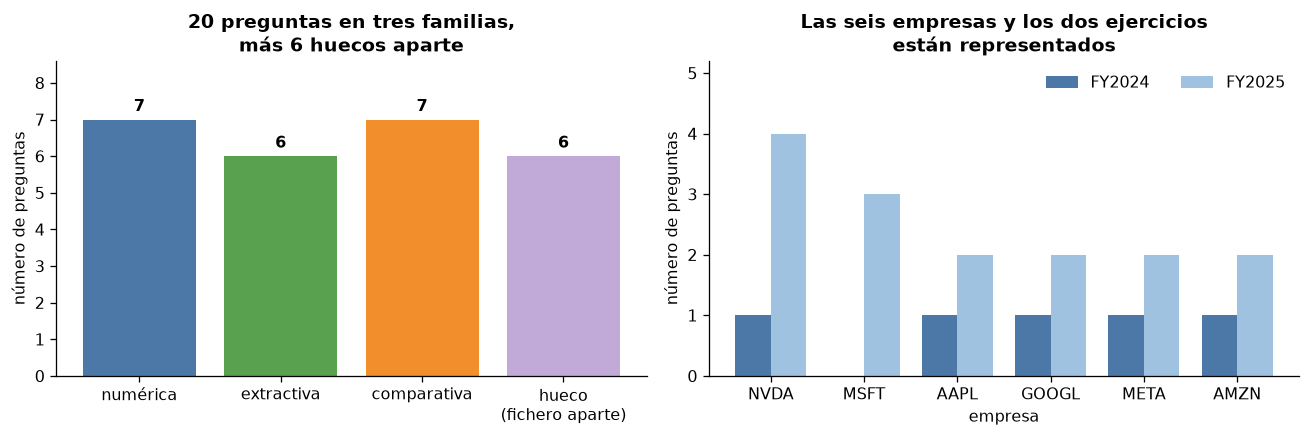

Apartados del informe cubiertos por las preguntas de texto: 1A, 7, 7A, 8


In [13]:
# Cómo ha quedado repartido el examen (se dibuja de lo ya construido, sin API)
reparto = g["familia"].value_counts().reindex(["numerica", "extractiva", "comparativa"])
reparto_total = pd.concat([reparto, pd.Series({"hueco": len(huecos)})])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.9))

barras = ax1.bar(range(len(reparto_total)), reparto_total.values,
                 color=[COLOR_FAMILIA[f] for f in reparto_total.index])
barras[-1].set_alpha(.55)          # los huecos no cuentan para las 20
ax1.bar_label(barras, padding=3, fontweight="bold")
ax1.set_xticks(range(len(reparto_total)),
               ["numérica", "extractiva", "comparativa", "hueco\n(fichero aparte)"])
ax1.set_ylabel("número de preguntas")
ax1.set_ylim(0, reparto_total.max() + 1.6)
ax1.set_title("20 preguntas en tres familias,\nmás 6 huecos aparte")

cobertura_golden = (pd.crosstab(g["ticker"], g["fiscal_year"])
                    .reindex(index=ORDEN_EMPRESAS, columns=[2024, 2025], fill_value=0))
xpos = np.arange(len(cobertura_golden))
ancho = .38
ax2.bar(xpos - ancho / 2, cobertura_golden[2024], ancho, color="#4C78A8", label="FY2024")
ax2.bar(xpos + ancho / 2, cobertura_golden[2025], ancho, color="#9EC2E0", label="FY2025")
ax2.set_xticks(xpos, cobertura_golden.index)
ax2.set_xlabel("empresa")
ax2.set_ylabel("número de preguntas")
ax2.set_ylim(0, cobertura_golden.to_numpy().max() + 1.2)
ax2.legend(frameon=False, ncol=2)
ax2.set_title("Las seis empresas y los dos ejercicios\nestán representados")

plt.tight_layout()
plt.show()

print("Apartados del informe cubiertos por las preguntas de texto:",
      ", ".join(sorted(g["item_esperado"].dropna().unique())))

**Qué nos dice esto:** el examen está repartido, no concentrado. Las cuatro familias están representadas, las seis empresas aparecen, los dos ejercicios también y las preguntas de texto tocan los cuatro apartados del informe. A partir de aquí, cualquier cambio en el agente se puede medir contra el mismo examen.